# Task 2.1 — Dataset Selection and Setup

## Dataset: Breast Cancer Wisconsin (Diagnostic)

**What it is:** The Breast Cancer Wisconsin dataset (sklearn built-in) contains 569 samples and 30 numeric features extracted from digitised images of fine-needle aspirate (FNA) biopsies. Each sample is labelled as malignant (1) or benign (0), making it a balanced binary classification task with real-valued continuous features.

**Why it is a reasonable testbed for CS4VM:** The paper's primary motivating application is medical diagnosis — specifically, that the cost of misclassifying a malignant tumour as benign (false negative) is far higher than classifying a benign tumour as malignant (false positive). This maps directly onto c(+1) >> c(−1) in the CS4VM framework. Furthermore, the dataset is large enough to simulate the semi-supervised setting (few labeled, many unlabeled) and its features produce well-separated class clusters in kernel space, satisfying the cluster assumption that CS4VM depends on.

**Limitations compared to the paper's datasets:** The original paper uses 20 UCI datasets with only 10 labeled examples per dataset. We use a slightly larger labeled set for stability. The paper also averages over 100 random splits; we use 30 for time efficiency. Additionally, the original paper uses a linear kernel throughout, which we also adopt, though the breast cancer data may benefit from an RBF kernel.

**Preprocessing:** Features are standardized (zero mean, unit variance) using sklearn's StandardScaler before any model fitting, since SVM performance is sensitive to feature scale.


In [1]:
print('hello world')

hello world


In [2]:
# ── Random seed (documented once at the top) ──────────────────────────────────
import numpy as np
import random
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── Imports ───────────────────────────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load dataset ──────────────────────────────────────────────────────────────
data = load_breast_cancer()
X_full = data.data
y_full = (data.target * 2 - 1).astype(float)   # convert to {-1, +1}

print(f"Dataset: Breast Cancer Wisconsin")
print(f"Total samples : {X_full.shape[0]}")
print(f"Features      : {X_full.shape[1]}")
print(f"Positive (+1) : {(y_full == 1).sum()}  (Malignant)")
print(f"Negative (-1) : {(y_full == -1).sum()} (Benign)")
print(f"Class ratio   : {(y_full==1).mean():.2%} positive")


Dataset: Breast Cancer Wisconsin
Total samples : 569
Features      : 30
Positive (+1) : 357  (Malignant)
Negative (-1) : 212 (Benign)
Class ratio   : 62.74% positive


The dataset is loaded. Labels are remapped to {+1, −1} as required by the CS4VM formulation (Eq. 2).

Training pool : 284 samples
Test set      : 285 samples
Labeled       : 10 samples  → 4 pos, 6 neg
Unlabeled     : 274 samples


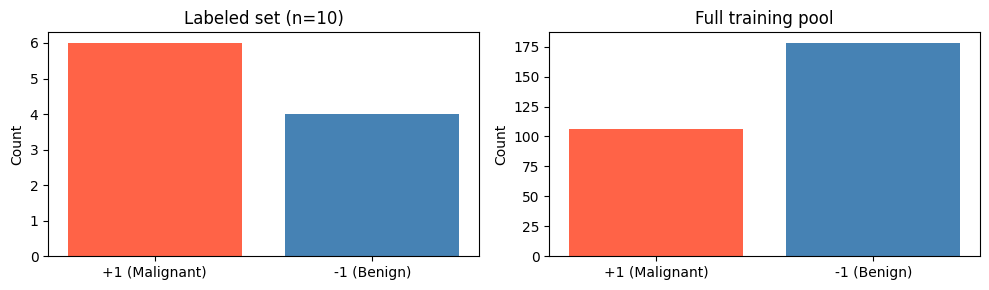

Saved: results/dataset_distribution.png


In [3]:
# ── Train / Test split ────────────────────────────────────────────────────────
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_full, y_full, test_size=0.5, random_state=SEED, stratify=y_full)

# ── Standardise (fit on train, transform both) ────────────────────────────────
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test        = scaler.transform(X_test)

print(f"Training pool : {X_train_full.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")

# ── Semi-supervised split: 10 labeled, rest unlabeled ─────────────────────────
N_LABELED = 10
idx = np.arange(len(X_train_full))
np.random.shuffle(idx)
lab_idx   = idx[:N_LABELED]
unlab_idx = idx[N_LABELED:]

X_labeled   = X_train_full[lab_idx]
y_labeled   = y_train_full[lab_idx]
X_unlabeled = X_train_full[unlab_idx]
y_unlabeled = y_train_full[unlab_idx]   # kept for evaluation only, not used during training

print(f"Labeled       : {len(X_labeled)} samples  → {(y_labeled==1).sum()} pos, {(y_labeled==-1).sum()} neg")
print(f"Unlabeled     : {len(X_unlabeled)} samples")

# ── Class distribution plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (labels, title) in zip(axes, [
        (y_labeled,   f"Labeled set (n={N_LABELED})"),
        (y_train_full, "Full training pool")]):
    vals, counts = np.unique(labels, return_counts=True)
    ax.bar(['+1 (Malignant)', '-1 (Benign)'], counts, color=['tomato','steelblue'])
    ax.set_title(title); ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(f"{'/Users/sourabhsarkarmacois/Desktop/230081-midsem/partB'}/results/dataset_distribution.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved: results/dataset_distribution.png")


The bar charts confirm the semi-supervised setup: only 10 labeled examples are used for training; the remaining 274 training samples are treated as unlabeled.